# Pràctica 4: Similitud Lèxica i Semàntica
Max Villalba i Biel Sánchez  
_Processament del Llenguatge Humà - GIA_
___

## Introducció

En aquesta pràctica explorarem models de **similitud lèxica i semàntica** entrenant i avaluant models d'embeddings distribucionals i contextuals.

Per començar, **importarem totes les llibreries** necessaries i **entrenarem els nostres propis models Word2Vec i FastText** fent servir un wikicorpus en espanyol. Farem un preprocessat adequat i analitzarem l'efecte que tenen els diferents hiperparàmetres, com ara la **dimensió dels embeddings** o la **mida del corpus**.

Seguidament, realitzarem una **avaluació intrínseca** d'aquests embeddings comparant-los amb un model de FastText oficial. A partir del dataset anotat **Multi-SimLex**, calcularem la correlació de ***Spearman*** per veure fins a quin punt les prediccions dels nostres models, les quals utilitzaran la similitud del cosinus, s'assemblen amb les puntuacions anotades per humans.

Finalment, explorarem diferents representacions en una **avaluació extrínseca** utilitzant el dataset de **Spanish STS**. Compararem tres models diferents: un ***baseline cosinus***, on calcularem la similitud cosinus entre les dues frases; un **Model Seqüencial Siamès**, el qual utilitza **atenció** i **BiLSTM** sobre **embeddings estàtics**; i finalment un model **BERT Siamès**, el qual utiliza frases tokenitzades amb BERT. Aquest procés ens servirà per veure **quin és el millor model** a l'hora de captar la semàntica de frases en conjunt i fer un **anàlisi definitiu dels resultats**.

Per tal de simplificar la lectura i la organització, hem decidit separar aquesta pràctica en tres *Notebooks* diferents, un per cada apartat demanat (indicats amb *Part1*, *Part2* i *Part3* respectivament).
___

# Pràctica 4 – Part 1: Entrenament d'Embeddings Estàtics

La primera part d'aquesta pràctica estarà dedicada a entrenar els nostres pròpis models de **Word2Vec** i **FastText** (tots dos amb *Skip-Gram*) a partir del wikicorpus en espanyol proporcionat: ***raw.es.tgz***. Finalment, analitzarem l'efecte de les dimensions dels embeddings i mida del corpus.

## 0. Instal·lació

Instalem les llibreries necessaries. En cas de tenir-ho tot ja instalat, omitim aquest pas.

In [ ]:
%pip install gensim -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\maxvi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 1. Imports i configuració

Per començar, importem **totes les llibreries** que necessitarem per aquesta primera part. A més, indiquem la ruta del **corpus** a utilitzar i creem la **carpeta** on es guardaran els models entrenats, aíxi com definim els **hiperparàmetres** que utilitzarem durant l'entrenament, concretament:
- Les **mides del corpus** (`CORPUS_SIZES`).
- Les **dimensions dels embeddings** (`DIMS`).
- La mida de la **finestra de context** (`WINDOW`).
- La **freqüencia mínima d'aparició** per incloure una paraula al vocabulari (`MIN_COUNT`).
- El nombre de **fils d'execució** (`WORKERS`).
- El **nombre d'epochs** (`EPOCHS`).

In [ ]:
import os, re, time, tarfile, pickle
from pathlib import Path
from gensim.models import Word2Vec, FastText
import warnings
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Generator, Iterator, Any, Dict, Optional, Union

warnings.filterwarnings("ignore")

# ── Ruta al corpus ──────────────────────────────────────────────────────────
# Accepta: fitxer .tgz, carpeta descomprimida raw.es/, o fitxer de text individual
CORPUS_PATH = "raw.es.tgz"

MODELS_DIR   = Path("models"); MODELS_DIR.mkdir(exist_ok=True)
CORPUS_SIZES = [100_000, 500_000, 1_000_000, 5_000_000]  # tokens
DIMS         = [25, 50, 100]
WINDOW       = 5
MIN_COUNT    = 5
WORKERS      = 4
EPOCHS       = 5

## 2. Preprocessat
Un cop importat tot el necessari, definirem la funció `preprocess` que ens servirà per **preprocessar el dataset**. Concretament, eliminarem les etiquetes XML, passarem el text a minúscules i eliminarem els signes de puntuació.

In [ ]:
_TAG = re.compile(r"<[^>]+>")
_PUN = re.compile(r"[^\w\s]", re.UNICODE)
_SPC = re.compile(r"\s+")

def preprocess(line: str) -> List[str]:
    """
    Elimina etiquetes XML, signes de puntuació i passa el text a minúscules, 
    retornant una llista de tokens.
    
    Args:
        line (str): La línia de text a processar.
        
    Returns:
        List[str]: Llista de tokens resultants.
    """
    line = _TAG.sub(" ", line)
    line = line.lower()
    line = _PUN.sub(" ", line)
    return _SPC.sub(" ", line).strip().split()

## 3. Iteradors de corpus

Per no carregar de cop tot el text a memòria, generarem **iteradors** per llegir i preprocessar les dades seqüencialment a mesura que es necessitin.

Implementarem tres **funcions d'iteració**: `_iter_file`, `_iter_dir` i `_iter_tgz`, per donar suport a diferents formats de dades: fitxers de text, carpetes de fitxers, i arxius comprimits *.tgz* respectivament. En funció de l'opció triada `iter_corpus` fa servir una o una altra.

In [ ]:
def _iter_file(path: Union[str, Path], max_tok: Optional[int]) -> Generator[List[str], None, None]:
    """
    Itera sobre les línies d'un fitxer de text introduït, 
    preprocessant i retornant els seus tokens.
    
    Args:
        path (Union[str, Path]): Ruta al fitxer de text.
        max_tok (Optional[int]): Nombre màxim de tokens a llegir abans d'aturar-se.
        
    Yields:
        Generator[List[str], None, None]: Generador de llistes de tokens referents a cada línia.
    """
    total = 0
    with open(path, encoding="iso-8859-1", errors="replace") as f:
        for line in f:
            toks = preprocess(line)
            if not toks: continue
            yield toks
            total += len(toks)
            if max_tok and total >= max_tok: return

def _iter_tgz(path: Union[str, Path], max_tok: Optional[int]) -> Generator[List[str], None, None]:
    """
    Itera sobre els fitxers d'un arxiu .tgz, 
    preprocessant i retornant els seus tokens.
    
    Args:
        path (Union[str, Path]): Ruta a l'arxiu .tgz.
        max_tok (Optional[int]): Nombre màxim de tokens a llegir abans d'aturar-se.
        
    Yields:
        Generator[List[str], None, None]: Generador de llistes de tokens referents a cada línia.
    """
    total = 0
    with tarfile.open(path, "r:gz") as tar:
        for member in tar:
            if not member.isfile(): continue
            f = tar.extractfile(member)
            if f is None: continue
            for raw in f:
                toks = preprocess(raw.decode("iso-8859-1", errors="replace"))
                if not toks: continue
                yield toks
                total += len(toks)
                if max_tok and total >= max_tok: return

def _iter_dir(path: Union[str, Path], max_tok: Optional[int]) -> Generator[List[str], None, None]:
    """
    Itera seqüencialment pels fitxers d'un directori, 
    preprocessant i retornant els seus tokens.
    
    Args:
        path (Union[str, Path]): Ruta al directori que conté els arxius.
        max_tok (Optional[int]): Nombre màxim de tokens a llegir abans d'aturar-se.
        
    Yields:
        Generator[List[str], None, None]: Generador de llistes de tokens referents a cada línia.
    """
    total = 0
    for fp in sorted(Path(path).iterdir()):
        if not fp.is_file(): continue
        for toks in _iter_file(fp, max_tok - total if max_tok else None):
            yield toks
            total += len(toks)
            if max_tok and total >= max_tok: return

def iter_corpus(path: Union[str, Path], max_tok: Optional[int]) -> Generator[List[str], None, None]:
    """
    Tria l'algorisme d'iteració adequat depenent si el path és un directori, 
    un .tgz o un fitxer normal.
    
    Args:
        path (Union[str, Path]): Ruta de l'arxiu, directori o arxiu comprimit a iterar.
        max_tok (Optional[int]): Nombre màxim de tokens a llegir abans d'aturar-se.
        
    Yields:
        Generator[List[str], None, None]: Generador de llistes de tokens referents a cada línia.
    """
    p = str(path)
    if   p.endswith((".tgz", ".tar.gz")): yield from _iter_tgz(p, max_tok)
    elif os.path.isdir(p):                yield from _iter_dir(p, max_tok)
    else:                                 yield from _iter_file(p, max_tok)

## 4. Càrrega del corpus en memòria

Degut a que algorismes com **Word2Vec** o **FastText** necessiten fer múltiples epochs, no podem llegir l'arxiu directament dins del procés d'entrenament, ja que això faria que anés molt lent. 

Per resoldre això definim la classe `MemoryCorpus`. El que fa és utilitzar les funcions que hem definit a la secció anterior per llegir i processar les frases fins arribar al **límit de tokens especificat** (`max_tok`, paràmetre que ens permetrà provar els entrenaments amb diferents mides de corpus com 100k, 500k, etc.). Aquestes frases processades es **guarden en una llista** perquè es puguin llegir moltes vegades **de forma ràpida**. A més, ens permet guardar fàcilment el **recompte real de tokens** i **frases que estem entrenant**.

In [ ]:
class MemoryCorpus:
    """
    Carrega el corpus en memòria fins arribar al límit 
    de tokens desitjat, optimitzant l'entrenament.
    """
    def __init__(self, path: Union[str, Path], max_tok: Optional[int]) -> None:
        """
        Inicialitza el corpus, llegint i preprocessant les dades inicials.
        
        Args:
            path (Union[str, Path]): Ruta al corpus que es vol carregar.
            max_tok (Optional[int]): Nombre màxim de tokens a carregar en memòria.
        """
        t0 = time.time()
        self.sentences: List[List[str]] = list(iter_corpus(path, max_tok))
        self.actual_tokens: int = sum(len(s) for s in self.sentences)
        print(f"  {len(self.sentences):,} frases | {self.actual_tokens:,} tokens | {time.time()-t0:.1f}s")
        
    def __iter__(self) -> Iterator[List[str]]: 
        """
        Retorna un iterador sobre les frases del corpus.
        
        Returns:
            Iterator[List[str]]: Iterador de les frases que s'han carregat en memòria.
        """
        return iter(self.sentences)
        
    def __len__(self) -> int:  
        """
        Retorna el total de frases llegides del corpus.
        
        Returns:
            int: Total de frases carregades al corpus en memòria.
        """
        return len(self.sentences)

## 5. Funcions d'entrenament

Finalment, definirem les dues funcions que ens permetran fer l'entrenament dels models de **Word2Vec** i **FastText**: `train_word2vec` i `train_fasttext` respectivament. Aquestes funcions defineixen i entrenen els models a partir de la **dimensió de l'embedding** i **la mida del corpus específicada**. A més, anoten el **temps necessari** per completar tot el procés (`time`) i la **mida del vocabulari creat** (`vocab`), és a dir, el nombre total de **paraules úniques** que el model ha après i ha guardat **després de filtrar** aquelles que apareixen menys vegades que el mínim indicat pel paràmetre `MIN_COUNT`.

In [ ]:
def train_word2vec(corpus: MemoryCorpus, dim: int, corpus_size: int) -> Dict[str, Any]:
    """
    Entrena i desa un model Word2Vec Skip-Gram per un corpus i dimensió determinats.
    
    Args:
        corpus (MemoryCorpus): L'objecte de `MemoryCorpus` on es troben les frases a utilitzar.
        dim (int): La dimensió de l'embedding a aplicar.
        corpus_size (int): La quantitat de tokens amb els quals s'entrenarà el model.
        
    Returns:
        Dict[str, Any]: Un diccionari que conté els detalls i els resultats de l'entrenament.
    """
    name = f"w2v_dim{dim}_tok{corpus_size//1000}k"
    print(f"[Word2Vec] {name} ...", end=" ", flush=True)
    t0 = time.time()
    model = Word2Vec(sentences=corpus, vector_size=dim, window=WINDOW,
                     min_count=MIN_COUNT, workers=WORKERS, epochs=EPOCHS, sg=1, seed=42)
    elapsed = time.time() - t0
    model.save(str(MODELS_DIR / f"{name}.model"))
    print(f"vocab={len(model.wv):,}  {elapsed:.1f}s")
    return {"name": name, "type": "Word2Vec", "dim": dim,
            "corpus_size": corpus_size, "actual_tokens": corpus.actual_tokens,
            "vocab": len(model.wv), "time": round(elapsed, 2)}

def train_fasttext(corpus: MemoryCorpus, dim: int, corpus_size: int) -> Dict[str, Any]:
    """
    Entrena i desa un model FastText Skip-Gram per un corpus i dimensió determinats.
    
    Args:
        corpus (MemoryCorpus): L'objecte de `MemoryCorpus` on es troben les frases a utilitzar.
        dim (int): La dimensió de l'embedding a aplicar.
        corpus_size (int): La quantitat de tokens amb els quals s'entrenarà el model.
        
    Returns:
        Dict[str, Any]: Un diccionari que conté els detalls i els resultats de l'entrenament.
    """
    name = f"ft_dim{dim}_tok{corpus_size//1000}k"
    print(f"[FastText]  {name} ...", end=" ", flush=True)
    t0 = time.time()
    model = FastText(sentences=corpus, vector_size=dim, window=WINDOW,
                     min_count=MIN_COUNT, workers=WORKERS, epochs=EPOCHS,
                     sg=1, min_n=3, max_n=6, seed=42)
    elapsed = time.time() - t0
    model.save(str(MODELS_DIR / f"{name}.model"))
    print(f"vocab={len(model.wv):,}  {elapsed:.1f}s")
    return {"name": name, "type": "FastText", "dim": dim,
            "corpus_size": corpus_size, "actual_tokens": corpus.actual_tokens,
            "vocab": len(model.wv), "time": round(elapsed, 2)}

## 6. Entrenament de tots els models

Un cop definides totes les funcions necessaries per aquesta primer part, passem a **l'entrenament dels models**.

La idea és básicament anar entrenant amb les **diferents combinacions** de `CORPUS_SIZES` i `DIMS` que hem definit a l'inici. Els resultats es guarden en un fitxer `results.pkl` per tal d'aprofitar-los en pròximes parts de la pràctica.

In [8]:
results = []

for corpus_size in CORPUS_SIZES:
    print(f"\n=== Corpus: {corpus_size:,} tokens ===")
    corpus = MemoryCorpus(CORPUS_PATH, corpus_size)

    for dim in DIMS:
        results.append(train_word2vec(corpus, dim, corpus_size))
        results.append(train_fasttext(corpus, dim, corpus_size))

    # Si el corpus és més petit que la mida sol·licitada, aturem
    if corpus.actual_tokens < corpus_size * 0.8:
        print("Corpus exhaurit. Aturant.")
        break

with open(MODELS_DIR / "results.pkl", "wb") as f:
    pickle.dump(results, f)


=== Corpus: 100,000 tokens ===
  7,185 frases | 100,012 tokens | 0.3s
[Word2Vec] w2v_dim25_tok100k ... vocab=2,572  1.0s
[FastText]  ft_dim25_tok100k ... vocab=2,572  2.7s
[Word2Vec] w2v_dim50_tok100k ... vocab=2,572  1.1s
[FastText]  ft_dim50_tok100k ... vocab=2,572  3.2s
[Word2Vec] w2v_dim100_tok100k ... vocab=2,572  1.0s
[FastText]  ft_dim100_tok100k ... vocab=2,572  4.1s

=== Corpus: 500,000 tokens ===
  23,912 frases | 500,008 tokens | 1.1s
[Word2Vec] w2v_dim25_tok500k ... vocab=9,832  5.3s
[FastText]  ft_dim25_tok500k ... vocab=9,832  12.8s
[Word2Vec] w2v_dim50_tok500k ... vocab=9,832  5.6s
[FastText]  ft_dim50_tok500k ... vocab=9,832  13.9s
[Word2Vec] w2v_dim100_tok500k ... vocab=9,832  5.7s
[FastText]  ft_dim100_tok500k ... vocab=9,832  14.1s

=== Corpus: 1,000,000 tokens ===
  47,108 frases | 1,000,026 tokens | 1.8s
[Word2Vec] w2v_dim25_tok1000k ... vocab=16,577  10.7s
[FastText]  ft_dim25_tok1000k ... vocab=16,577  27.4s
[Word2Vec] w2v_dim50_tok1000k ... vocab=16,577  12.4s


## 7. Resum de resultats

Ara que ja tenim els models entrenats, analitzarem quins resultats hem obtingut en relació a la **dimensionalitat dels embeddings** i la **mida del corpus**.

In [9]:
print(f"{'Model':<32} {'Dim':>5} {'Corpus':>8} {'Tokens':>12} {'Vocab':>8} {'Temps':>7}")
print("-" * 76)
for r in results:
    print(f"{r['name']:<32} {r['dim']:>5} {r['corpus_size']//1000:>7}k "
          f"{r['actual_tokens']:>12,} {r['vocab']:>8,} {r['time']:>6.1f}s")

Model                              Dim   Corpus       Tokens    Vocab   Temps
----------------------------------------------------------------------------
w2v_dim25_tok100k                   25     100k      100,012    2,572    1.0s
ft_dim25_tok100k                    25     100k      100,012    2,572    2.7s
w2v_dim50_tok100k                   50     100k      100,012    2,572    1.1s
ft_dim50_tok100k                    50     100k      100,012    2,572    3.2s
w2v_dim100_tok100k                 100     100k      100,012    2,572    1.0s
ft_dim100_tok100k                  100     100k      100,012    2,572    4.1s
w2v_dim25_tok500k                   25     500k      500,008    9,832    5.3s
ft_dim25_tok500k                    25     500k      500,008    9,832   12.8s
w2v_dim50_tok500k                   50     500k      500,008    9,832    5.6s
ft_dim50_tok500k                    50     500k      500,008    9,832   13.9s
w2v_dim100_tok500k                 100     500k      500,008    9

Si analitzem la sortida podem veure alguns detalls interessants. En primer lloc, **FastText** és més lent que **Word2Vec** en **tots els casos**, de fet tarda més o menys el **doble de temps** en completar el procés. Això pot ser degut a que **FastText** no només calcula embeddings per a les paraules senceres, sinó que també **calcula i actualitza** els embeddings de les "sub-paraules" (n-grames de caràcters), la qual cosa incrementa significativament el temps de l'entrenament. 

A més, podem veure que curiosament el nombre de tokens utilitzats **no coincideix** exactament amb la **mida del corpus especificada** (per exemple, 100.012 en lloc de 100.000). Aquesta diferencia possiblement es deu a que la nostra funció d'iteració del corpus llegeix les dades **línia a línia**, i quan arriba o supera el límit establert (com els 100k), ja ha llegit tota l'última línia sencera i hi suma els tokens que queden abans d'aturar-se. Aquesta decisió de disseny ens permet, per tant, **no truncar les frases pel mig** i assegurar-nos que entrenem patrons vàlids per a les darreres paraules.

Finalment, també podem concloure que el que realment **fa pujar el temps** és la **mida del corpus**, mentre que la dimensionalitat dels embeddings no mostra un efecte tant clar. Es pot observar el mateix amb el **vocabulari**, on únicament augmenta al **incrementar la mida del corpus**.

A continuació, observarem els mateixos resultats d'una forma més visual:

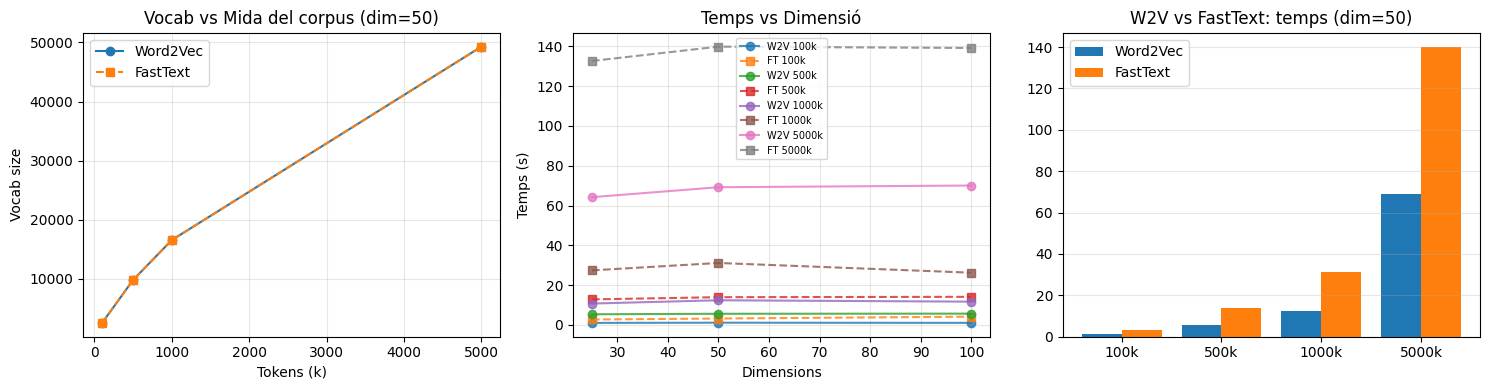

In [ ]:
w2v   = [r for r in results if r["type"] == "Word2Vec"]
ft    = [r for r in results if r["type"] == "FastText"]
sizes = sorted(set(r["corpus_size"] for r in results))
dims  = sorted(set(r["dim"] for r in results))
dim_mid = dims[len(dims)//2]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Vocab vs corpus size
vocab_w2v = [next(r["vocab"] for r in w2v if r["corpus_size"]==s and r["dim"]==dim_mid) for s in sizes]
vocab_ft  = [next(r["vocab"] for r in ft  if r["corpus_size"]==s and r["dim"]==dim_mid) for s in sizes]
axes[0].plot([s/1000 for s in sizes], vocab_w2v, "o-", label="Word2Vec")
axes[0].plot([s/1000 for s in sizes], vocab_ft,  "s--", label="FastText")
axes[0].set_xlabel("Tokens (k)"); axes[0].set_ylabel("Vocab size")
axes[0].set_title(f"Vocab vs Mida del corpus (dim={dim_mid})")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Temps vs dimensió
for size in sizes:
    tw = [next(r["time"] for r in w2v if r["corpus_size"]==size and r["dim"]==d) for d in dims]
    tf = [next(r["time"] for r in ft  if r["corpus_size"]==size and r["dim"]==d) for d in dims]
    axes[1].plot(dims, tw, "o-",  label=f"W2V {size//1000}k", alpha=0.8)
    axes[1].plot(dims, tf, "s--", label=f"FT {size//1000}k",  alpha=0.8)
axes[1].set_xlabel("Dimensions"); axes[1].set_ylabel("Temps (s)")
axes[1].set_title("Temps vs Dimensió")
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

# W2V vs FT temps
t_w = [next(r["time"] for r in w2v if r["corpus_size"]==s and r["dim"]==dim_mid) for s in sizes]
t_f = [next(r["time"] for r in ft  if r["corpus_size"]==s and r["dim"]==dim_mid) for s in sizes]
x = np.arange(len(sizes))
axes[2].bar(x - 0.2, t_w, 0.4, label="Word2Vec")
axes[2].bar(x + 0.2, t_f, 0.4, label="FastText")
axes[2].set_xticks(x); axes[2].set_xticklabels([f"{s//1000}k" for s in sizes])
axes[2].set_title(f"W2V vs FastText: temps (dim={dim_mid})")
axes[2].legend(); axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("grafic_entrenament.png", dpi=120, bbox_inches="tight")
plt.show()

Amb aquests gràfics podem observar els mateixos resultats que hem comentat abans. Primerament, el **vocabulari augmenta** clarament al **augmentar també la mida del corpus**. També podem observar que, tal i com hem dit abans, els temps **no varia de manera significativa** quan **augmentem la dimensió dels embeddings**. I finalment, podem veure com **FastText** és més lent que **Word2Vec** per a totes les mides del corpus.

## 8. Conclusions

L'entrenament dels models **Word2Vec** i **FastText** ens ha demostrat que **FastText** és consistentment **més lent** degut al cost de calcular representacions per n-grames de caràcters. 

Hem observat que **incrementar la mida del corpus** augmenta significativament la mida del vocabulari i el temps d'entrenament, mentre que **la dimensió dels embeddings** no té un impacte rellevant en cap dels dos tipus de models.